# Лабораторная работа №1. Анализ датасета, пропуски и их заполнение



## 1. Синтезирование датасета `dfS00`

Требуется 1000 объектов с 4 признаками и **ровно** заданной выборочной корреляционной
матрицей: между A и B корреляция 0.9, все остальные пары независимы.

Схема: сгенерировать независимые признаки → привести к ортонормированному базису
QR-разложением → умножить на нижнетреугольный множитель Холецкого от нужной матрицы `R`.

Ключевой момент — множитель $\sqrt{n-1}$: столбцы `Q` имеют единичную норму, а
выборочная ковариация pandas делится на $(n-1)$, поэтому без этого множителя
выборочная корреляция вышла бы 0.9 / 999 ≈ 0.0009.

In [ ]:
np.random.seed(42)
n_samples, n_features = 1000, 4

R = np.array([[1.0, 0.9, 0.0, 0.0],
              [0.9, 1.0, 0.0, 0.0],
              [0.0, 0.0, 1.0, 0.0],
              [0.0, 0.0, 0.0, 1.0]])

X = np.random.multivariate_normal(np.zeros(n_features), np.eye(n_features),
                                  size=n_samples)
X_centered = X - X.mean(axis=0)          # выборочное среднее строго 0
Q, _ = np.linalg.qr(X_centered)          # ортонормированный базис
L = np.linalg.cholesky(R)                # R = L @ L.T
Y = Q * np.sqrt(n_samples - 1) @ L.T     # множитель sqrt(n-1) => ровно R

dfS00 = pd.DataFrame(Y, columns=['A', 'B', 'C', 'D'])
dfS00['class'] = 'class_1'

dfS00[['A', 'B', 'C', 'D']].corr()

[font] discovered 'Nimbus Sans' at /usr/share/fonts/urw-base35/NimbusSans-Regular.otf
Корреляционная матрица выборки dfS00:
              A             B             C             D
A  1.000000e+00  9.000000e-01 -2.667202e-18 -4.067484e-17
B  9.000000e-01  1.000000e+00  1.244694e-17 -2.639419e-17
C -2.667202e-18  1.244694e-17  1.000000e+00  4.723171e-18
D -4.067484e-17 -2.639419e-17  4.723171e-18  1.000000e+00


## 2. Описательные статистики

Ключевое наблюдение: **средние равны нулю, стандартные отклонения равны единице** —
признаки нормированы. Это важно для всех дальнейших пунктов: медиана должна
оказаться около нуля, а в формулах для допусков удобно пользоваться числами ~0.1.

In [ ]:
print(f"Всего объектов: {dfS00.shape[0]}, признаков: {dfS00.shape[1]}")
print(f"Классы: {dfS00['class'].value_counts().to_dict()}")

dfS00.describe().T.round(4)

dfS00[['A', 'B', 'C', 'D']].isna().sum()   # пропусков нет

1. РАЗМЕРНОСТЬ ДАТАСЕТА
Общее количество объектов (строк): 1000
Общее количество признаков (столбцов): 5

2. ТИП КАЖДОГО ПРИЗНАКА
      Тип данных
A        float64
B        float64
C        float64
D        float64
class        str

3. КОЛИЧЕСТВО КЛАССОВ И ОБЪЕКТОВ В КАЖДОМ ИЗ НИХ
         Количество объектов  Доля (%)
Класс                                 
class_1                 1000     100.0

4. ИНЫЕ ОЦЕНКИ ВЫБОРКИ (основные статистики)
    count  mean  std     min     25%     50%     75%     max
A  1000.0   0.0  1.0 -3.3327 -0.6580 -0.0265  0.6677  3.1643
B  1000.0  -0.0  1.0 -2.9561 -0.7042  0.0190  0.6200  3.3716
C  1000.0  -0.0  1.0 -3.2579 -0.6723  0.0130  0.6674  3.2489
D  1000.0  -0.0  1.0 -2.9925 -0.7042 -0.0105  0.6716  3.8709

5. ЧИСЛО ОБЪЕКТОВ С NaN ПО КЛАССАМ
         A  B  C  D
class              
class_1  0  0  0  0

6. ЧИСЛО ОБЪЕКТОВ СО ЗНАЧЕНИЕМ 0 ПО КЛАССАМ
         A  B  C  D
class              
class_1  0  0  0  0

ПРИМЕЧАНИЕ: Для непрерывных величин с плавающей 

## 3. Все признаки на одном графике (raincloud)

Видно, что **все четыре признака имеют одинаковую форму** — это подтверждает
нормировку: отличие A и B от C и D проявится не здесь, а в совместном
распределении (следующий пункт).

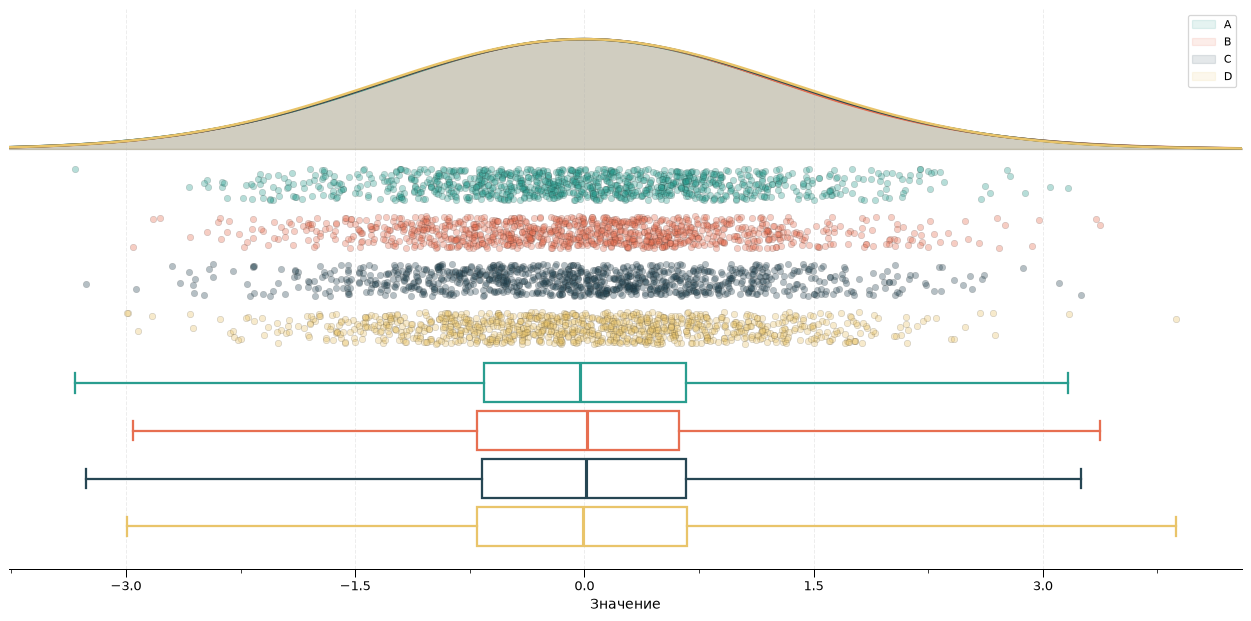

In [ ]:
df_long = dfS00.melt(id_vars=['class'], value_vars=['A', 'B', 'C', 'D'],
                     var_name='feature', value_name='value')

fig, ax = plt.subplots(figsize=(14, 7))
raincloud.raincloud_horizontal(
    dataset=df_long, feature_name='value', points_start_y=2.0,
    class_column='feature', class_order=['A', 'B', 'C', 'D'],
    class_colors=class_colors, boxplot_whiskers=(0, 100), axis=ax,
    kde_alpha=0.12, x_label='Значение', show_legend=True)
fig.tight_layout()

## 4. [1.5] Корреляция Пирсона и Спирмена

Тепловые карты в оформлении пункта [1.5]: подписи коэффициентов внутри ячеек,
палитра `coolwarm`, фиксированный диапазон $[-1; 1]$, квадратные ячейки.

Обе карты идентичны по смыслу: r(A,B) = 0.90, остальные коэффициенты порядка
$10^{-2}$. Совпадение Пирсона и Спирмена означает, что связь A–B **линейная**,
а не монотонная нелинейная (иначе Спирмен заметно отличался бы).


9. КОРРЕЛЯЦИЯ ПИРСОНА И СПИРМЕНА (HEATMAP)
Построение heat-map для всего датасета...
Построение heat-map для класса: class_1
Визуализация корреляций завершена.


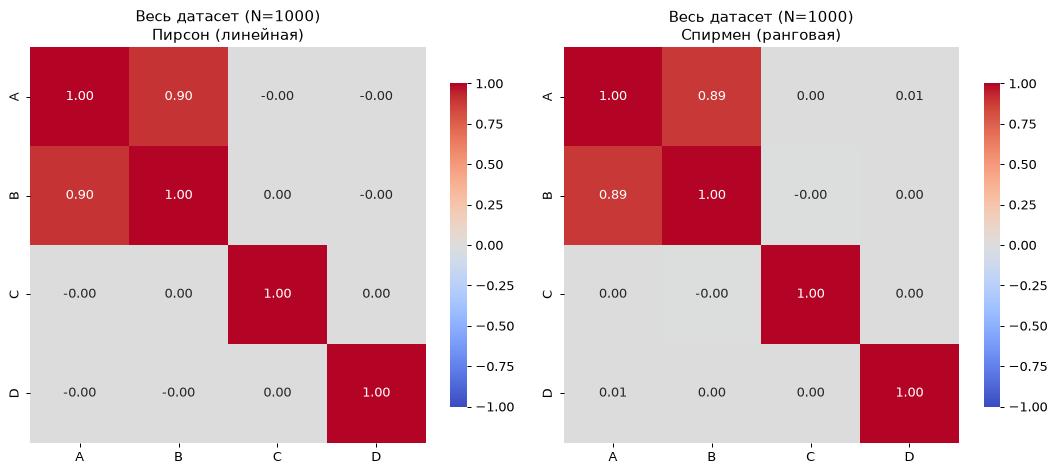

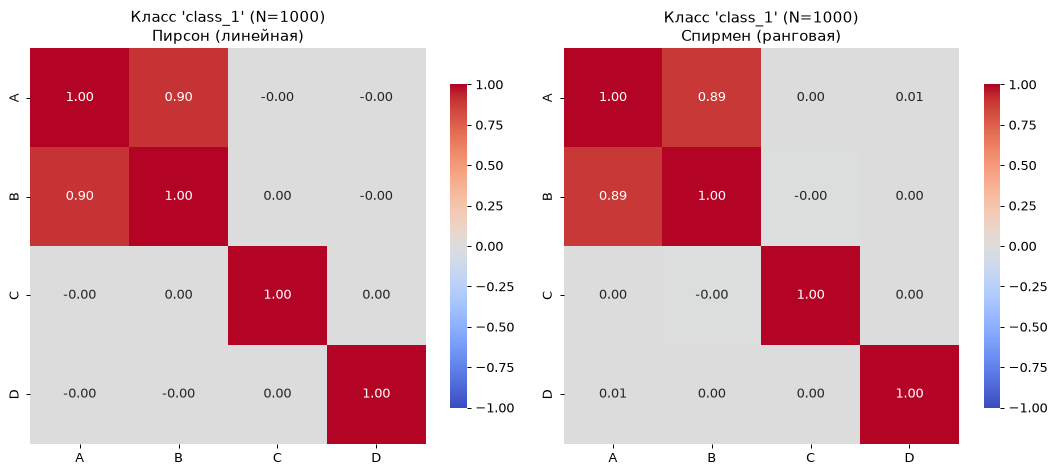

In [ ]:
sns.heatmap(dfS00[features].corr(method='pearson'), annot=True, cmap='coolwarm',
            vmin=-1, vmax=1, fmt=".2f", square=True)
sns.heatmap(dfS00[features].corr(method='spearman'), annot=True, cmap='coolwarm',
            vmin=-1, vmax=1, fmt=".2f", square=True)

## 5. [1.4] 2D-визуализация по всем парам выбранных переменных

Для **каждой** пары из `combinations(['A','B','C','D'], 2)` (всего $\binom{4}{2} = 6$)
строится:

* диаграмма рассеяния объектов — точки класса разной **формы** и **цвета**;
* маргинальные диаграммы плотности **каждого класса** вдоль обеих осей, различающиеся
  цветом и прозрачностью (сверху — по X, справа — по Y).

Обе части рисунка используют один и тот же движок `plots/scatterplot.py`.

### Регулируемые пользователем параметры

Всё оформление собрано в одном словаре `PAIR_VIS`:

| группа | ключи |
|---|---|
| квадратность | `figure.size`, `figure.square`, `figure.aspect`, `figure.plot_fraction` |
| оси | `axes.color`, `axes.linewidth`, `axes.spines`, `axes.square_data_area` |
| риски | `ticks.major_count`, `major_start`, `major_step`, `minor_count`, `minor_labels` |
| сетка | `grid.show`, `grid.minor`, цвета, прозрачность, стиль линии |
| шрифты | `font.size` и `font.family_by_role` — **отдельно** для подписей осей, делений, заголовка, легенды |
| прозрачность | `points.alpha` (или `alpha_mode="auto"`), `marginal.alpha` |
| отключение | `title.show = False`, `legend.show = False`, `marginal.show = False` |

### Что видно на рисунках

* **A–B** — вытянутое облако вдоль диагонали (r = 0.9).
* **A–C, A–D, B–C, B–D, C–D** — круглые облака без структуры.
* У одиночного класса `class_1` маргинальные плотности показывают нормальное
  распределение; при нескольких классах они накладываются разными цветами.


10. ДВУМЕРНАЯ ВИЗУАЛИЗАЦИЯ ПО ВСЕМ ПАРАМ ПРИЗНАКОВ
Рисуем точки классов разными формой/цветом и маргинальные плотности каждого класса по обеим осям.
  пара признаков: X = A, Y = B
  пара признаков: X = A, Y = C
  пара признаков: X = A, Y = D
  пара признаков: X = B, Y = C
  пара признаков: X = B, Y = D
  пара признаков: X = C, Y = D
Построено рисунков: 6 (по одному на пару признаков).


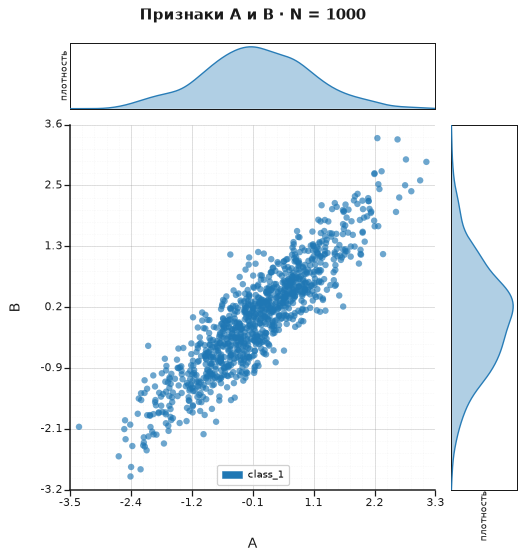

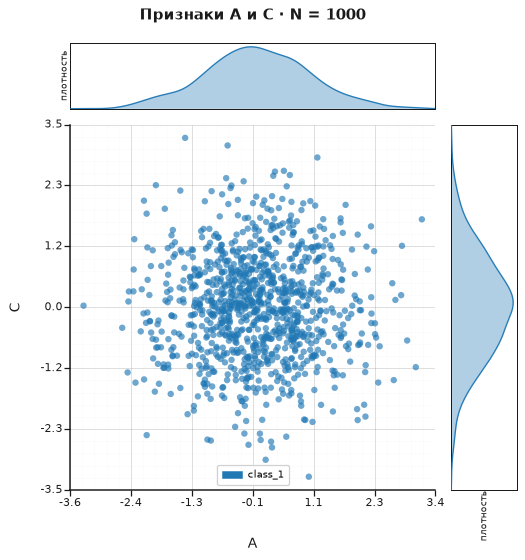

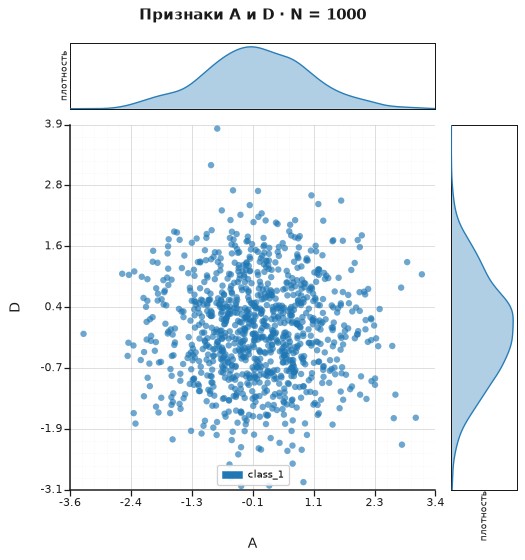

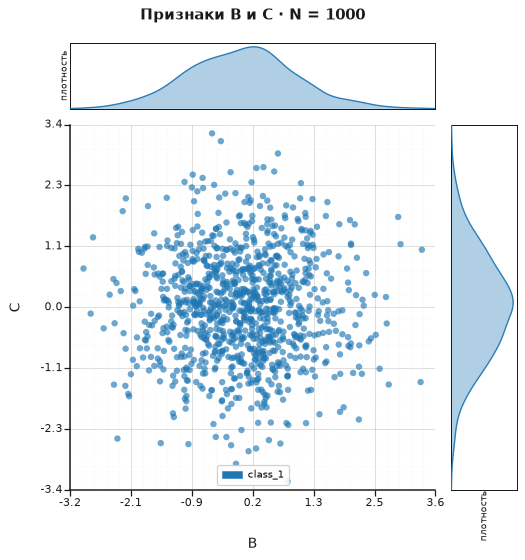

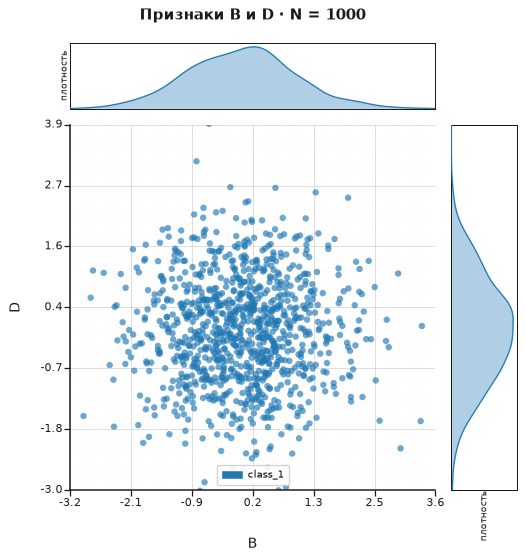

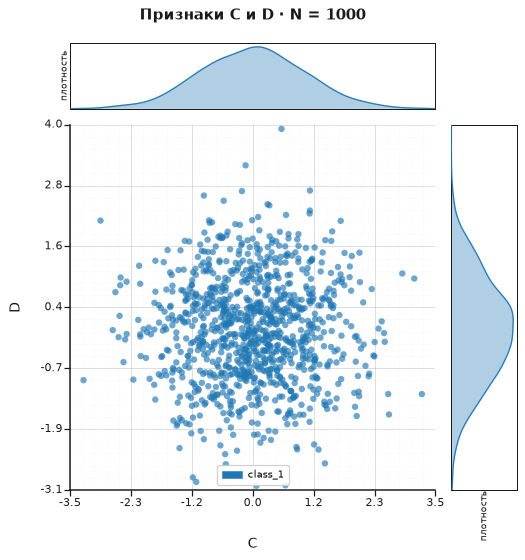

In [ ]:
PAIR_VIS = {
    "variables": ["A", "B", "C", "D"],
    "class_column": "class",
    "pairs": None,                       # None -> все пары из combinations(...)
    "title":  {"show": True, "template": "Признаки {x} и {y} · N = {n}"},
    "legend": {"show": True, "loc": "best", "frame": True, "alpha": 0.9},
    "figure": {"size": 7.0, "square": True, "aspect": 1.0,
               "plot_fraction": 0.58, "plot_fraction_plain": 0.80},
    "axes":   {"color": "#1a1a1a", "linewidth": 1.2, "spines": "left_bottom",
               "square_data_area": True, "margin": 0.04, "xlim": None, "ylim": None},
    "ticks":  {"show": True, "major_count": 7, "major_step": None, "minor_count": 4,
               "minor_labels": False, "major_size": 5.0, "width": 1.0},
    "grid":   {"show": True, "minor": True, "color": "#7a7a7a", "alpha": 0.25,
               "linestyle": "-", "linewidth": 0.7},
    "points": {"size": 26.0, "alpha": 0.65, "alpha_mode": "fixed", "size_auto": True},
    "class_style": {"palette": ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", ...],
                    "shapes": ["circle", "square", "diamond", "triangle_up", ...],
                    "per_class": {}},
    "font":   {"family": "DejaVu Sans",
               "size": {"tick": 9, "label": 11, "title": 12, "legend": 8,
                        "marginal": 7, "colorbar": 7},
               "family_by_role": {}, "weight": {"title": "bold"}},
    "marginal": {"show": True, "bw_method": "scott", "normalise": "density",
                 "scale": "per_class", "alpha": 0.35, "line_width": 1.1},
}

PAIR_FIGURES = plot_all_feature_pairs(dfS00)      # 6 рисунков: A-B, A-C, ...

## 6. [1.7] Клоны `dfSdXX` со случайно удалёнными ячейками

Из `dfS00` делаются копии, в которых значение заданного пользователем процента ячеек
заменено на `NaN`: 0 %, 1 %, 2 %, 5 %, 10 %, 20 %, 50 %, 80 %.

Пропуски **случайны** и не зависят от значений (MCAR), поэтому их можно оценить.
Число удалённых ячеек: $n_{\text{del}} = \mathrm{round}(p/100 \cdot 4000)$.

Для выбранной пары признаков каждый клон изображается панно $2 \times 4$ из диаграмм
рассеяния. **Общие пределы осей** во всех клетках — иначе картинки нельзя сравнивать.

### Что происходит с числом объектов

Из точки удалено 20 % ячеек из 4 признаков, значит в среднем 0.8 непустых ячейки на
объект. Объект, у которого хотя бы одно из **двух** выбранных значений стёрто, на
диаграмму не попадает:

| клон | объектов на графике A–B | строк отброшено |
|---|---|---|
| `dfSd00` | 1000 | 0 |
| `dfSd01` | 982 | 18 |
| `dfSd10` | 817 | 183 |
| `dfSd50` | 262 | 738 |
| `dfSd80` | **37** | 963 |

При 80 % удалённых ячеек на графике остаётся 37 объектов из 1000 — это
ожидаемое поведение «удалённых данных», а не ошибка.


11. КЛОНИРОВАНИЕ ДАТАСЕТА С УДАЛЁННЫМИ ЯЧЕЙКАМИ + ПАННО SCATTERPLOT
Проценты удаляемых ячеек: [0, 1, 2, 5, 10, 20, 50, 80]
Пара признаков на панно: X = A, Y = B
  dfSd00: удалено     0 из 4000 ячеек (  0 %), строк в клоне: 1000
  dfSd01: удалено    40 из 4000 ячеек (  1 %), строк в клоне: 1000
  dfSd02: удалено    80 из 4000 ячеек (  2 %), строк в клоне: 1000
  dfSd05: удалено   200 из 4000 ячеек (  5 %), строк в клоне: 1000
  dfSd10: удалено   400 из 4000 ячеек ( 10 %), строк в клоне: 1000
  dfSd20: удалено   800 из 4000 ячеек ( 20 %), строк в клоне: 1000
  dfSd50: удалено  2000 из 4000 ячеек ( 50 %), строк в клоне: 1000
  dfSd80: удалено  3200 из 4000 ячеек ( 80 %), строк в клоне: 1000
Общие пределы осей панно: X = [-3.59, 3.42], Y = [-3.21, 3.62]
  панно, клетка 1/8 (dfSd00): нарисовано объектов 1000
  панно, клетка 2/8 (dfSd01): нарисовано объектов 982, строк отброшено из-за удалённых ячеек: 18
  панно, клетка 3/8 (dfSd02): нарисовано объектов 961, строк отброшено из-за удалённых 

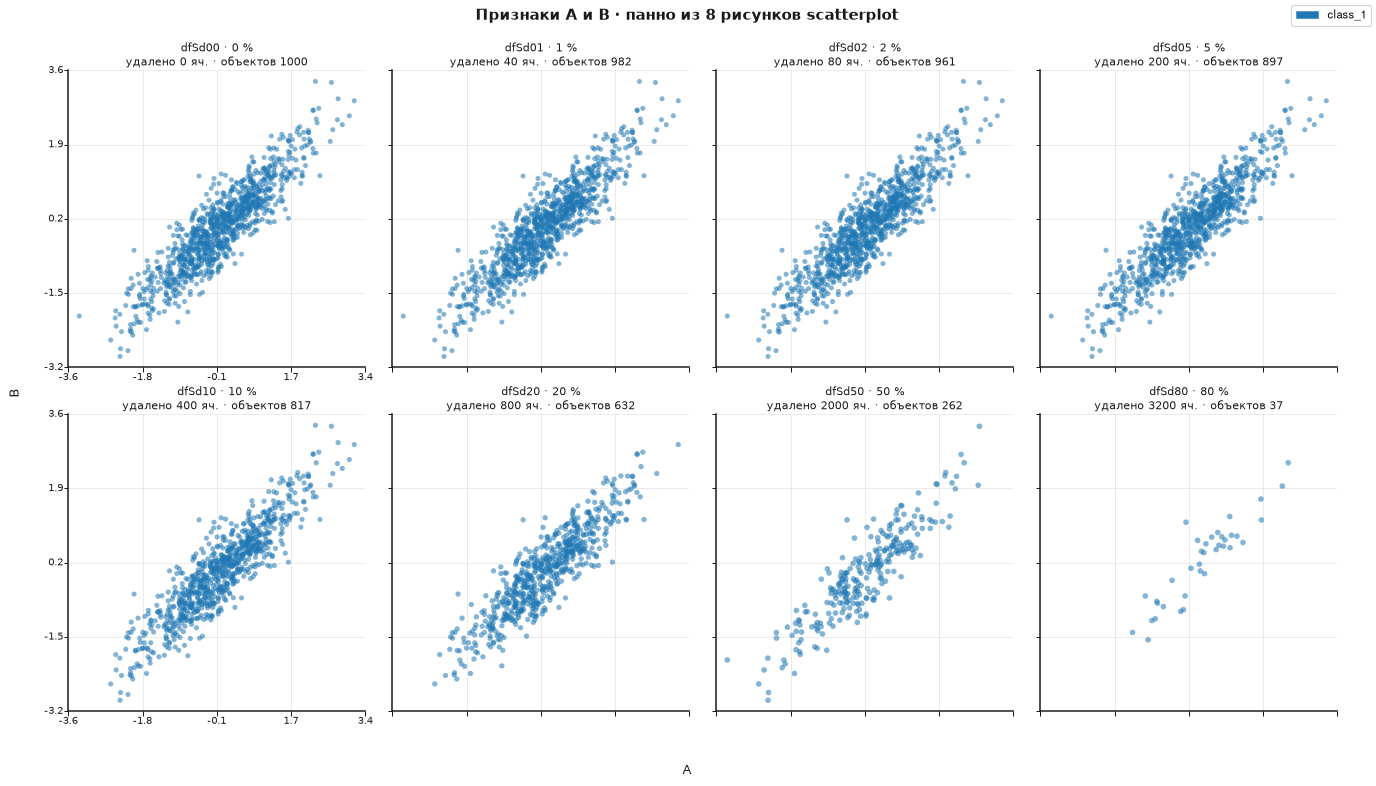

In [ ]:
DELETION_VIS = {
    "percentages": [0, 1, 2, 5, 10, 20, 50, 80],   # доля удаляемых ячеек, %
    "columns": None,          # None -> все числовые признаки (классы не трогаем)
    "seed": 42,               # воспроизводимость случайного удаления
    "class_column": "class",
    "x": "A", "y": "B",       # выбираемая пара
    "shared_limits": True,    # общие пределы осей во всех клетках
    "panel": {"ncols": None, "cell_size": 3.3, "tick_labels": "outer",
              "legend": True, "cell_title": "{name} · {percent} %\n"
                                       "удалено {n_del} яч. · объектов {objects}"},
}

DF_SD, DELETION_REPORT = build_deletion_datasets(dfS00)          # 8 клонов
DELETION_FIG = plot_deletion_panel(DF_SD, report=DELETION_REPORT, source=dfS00)

## 7. [1.6] Заполнение пропусков медианой: `dfSdXXmed`

Каждый клон `dfSdXX` превращается в `dfSdXXmed`, где все `NaN` заменены медианой
**своего** столбца. Дальше — панно scatterplot по всем восьми клонам и heatmap
корреляции Пирсона.

### Математика: почему медиана портит корреляцию

Медиана каждого столбца близка к нулю, поэтому все заполненные точки A лежат на
вертикали $x \approx 0$, а все заполненные точки B — на горизонтали $y \approx 0$.
**Крест** на графике — это не артефакт рисования, а прямое следствие метода.

Проверка: заполненные значения совпадают с медианой клона **точно** (191/191, 212/212,
198/198, 199/199), а известные значения не меняются ни на бит.

### Последствия для корреляции

| метод | r(A,B) | max abs(Δr) |
|---|---|---|
| истина | 0.900 | — |
| `dfSd20med` | **0.694** | 0.206 |
| `dfSd20knn` | 0.759 | 0.141 |
| `dfSd20reg` | 0.930 | 0.046 |
| `dfSd20mice` | 0.931 | 0.031 |

Медиана занижает r(A,B) сильнее всех: она ломает ровно ту связь, которая в данных
и есть. При этом по **суммарному** отклонению всех коэффициентов медиана «лучше»
kNN — метрика врёт, если смотреть только на неё.


12. ЗАПОЛНЕНИЕ ПРОПУСКОВ МЕДИАНОЙ + HEATMAP КОРРЕЛЯЦИИ ПИРСОНА
Пара признаков для панно scatterplot: X = A, Y = B
Заполнение пропусков медианой (источник медианы: clone)
  dfSd00med: заполнено     0 ячеек медианой, осталось пропусков: 0
  dfSd01med: заполнено    40 ячеек медианой, осталось пропусков: 0
  dfSd02med: заполнено    80 ячеек медианой, осталось пропусков: 0
  dfSd05med: заполнено   200 ячеек медианой, осталось пропусков: 0
  dfSd10med: заполнено   400 ячеек медианой, осталось пропусков: 0
  dfSd20med: заполнено   800 ячеек медианой, осталось пропусков: 0
  dfSd50med: заполнено  2000 ячеек медианой, осталось пропусков: 0
  dfSd80med: заполнено  3200 ячеек медианой, осталось пропусков: 0
Общие пределы осей панно: X = [-3.59, 3.42], Y = [-3.21, 3.62]
  панно, клетка 1/8 (dfSd00med): нарисовано объектов 1000
  панно, клетка 2/8 (dfSd01med): нарисовано объектов 1000
  панно, клетка 3/8 (dfSd02med): нарисовано объектов 1000
  панно, клетка 4/8 (dfSd05med): нарисовано объектов 100

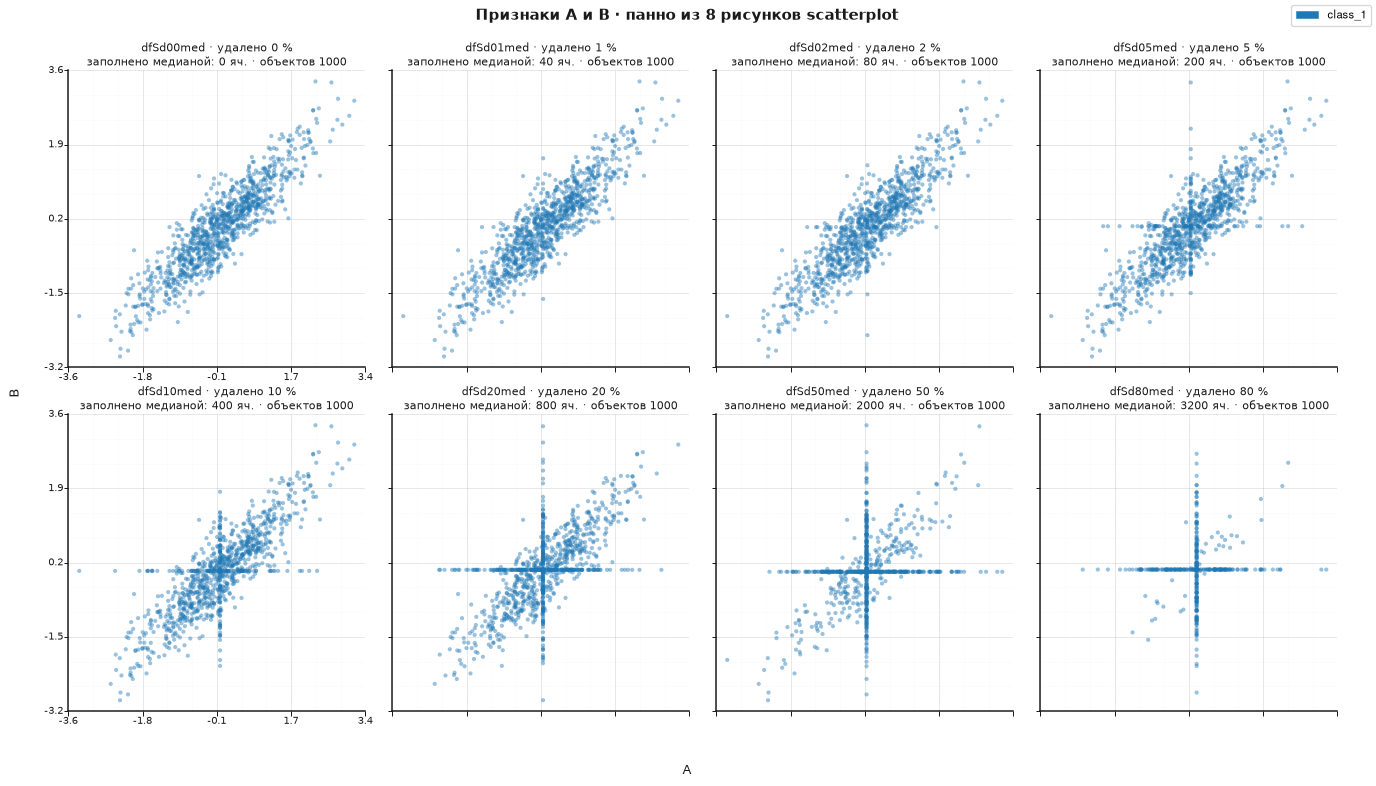

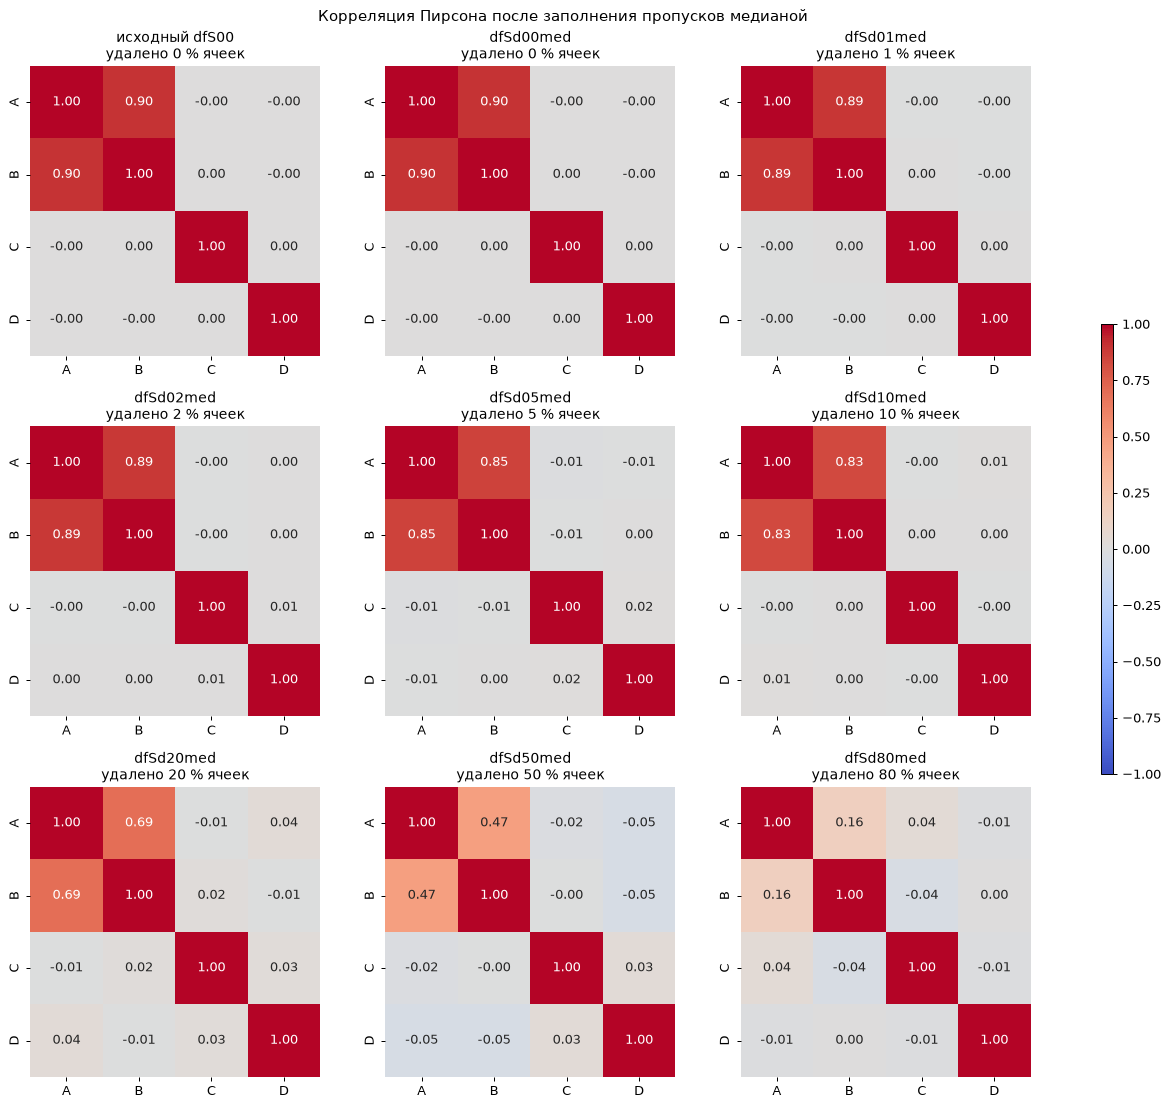

In [ ]:
IMPUTE_VIS = {
    "median_source": "clone",          # или "original" -> медиана из dfS00
    "x": "A", "y": "B",
    "style": {"points": {"size": 11.0, "alpha": 0.45}},
    "panel": {"cell_title": "{name} · удалено {percent} %\n"
                            "заполнено медианой: {n_del} яч. · объектов {objects}"},
    "heatmap": {"columns": None, "cbar": "shared", "cell_size": 3.6,
                "cmap": "coolwarm", "vmin": -1.0, "vmax": 1.0},
}

DF_SD_MED, FILLED_MED = build_imputed_datasets(DF_SD, source=dfS00)   # dfSdXXmed
MED_FIG    = plot_imputed_panel(DF_SD_MED, report=DELETION_REPORT,
                                source=dfS00, filled=FILLED_MED)
PEARSON_FIG, _ = plot_pearson_panel(DF_SD_MED, report=DELETION_REPORT, source=dfS00)

## 8. [1.8] Сравнение четырёх методов заполнения

Берётся **один** клон (`dfSd20`) и строятся четыре его версии:

| суффикс | метод | реализация |
|---|---|---|
| `med` | медианами | `fillna` медианой столбца |
| `knn` | kNN-заполнение | `sklearn.impute.KNNImputer`, 5 соседей, веса по расстоянию |
| `reg` | регрессионное | для каждого признака OLS по остальным (или Ridge / лес) |
| `mice` | MICE | `sklearn.impute.IterativeImputer`, 10 итераций |

Выводятся: heatmap корреляции Пирсона для `dfSd00`, самого клона и четырёх
заполненных версий, и **два панно** scatterplot — по парам A+B и C+D.

### Проверка геометрии (почему графики верны)

Генератор устроен как $A = 0.9\,B + \sqrt{1-0.9^2}\,\varepsilon$, поэтому OLS
даёт коэффициент $\hat\beta_B \approx 0.885$ при нулевых коэффициентах на C и D.
Из этого следуют **проверяемые** утверждения:

* **med** — 368 заполненных точек в паре (A,B), и **все 368** лежат на кресте
  (x = медиана A или y = медиана B);
* **reg / mice** — 280 и 270 точек из 368 лежат на прямых $A = 0.885\,B$ и
  $B = 0.885\,A$; остальные — на самом кресте не лежат;
* **knn** — ни одной точки на кресте, значения лежат внутри выпуклой оболочки
  наблюдённых точек (0 выходов за `min`/`max` — проверено для всех признаков);
* для **независимых** C и D информации нет, поэтому заполнение обязано
  «схлопнуться»: у `reg` и `mice` стд заполненных значений C и D падает до
  0.08 и 0.00 против 1.00 у наблюдённых.


13. СРАВНЕНИЕ МЕТОДОВ ЗАПОЛНЕНИЯ ПРОПУСКОВ
Выбранный клон: dfSd20
Пары признаков: [('A', 'B'), ('C', 'D')]
Методы: ['медианами', 'kNN-заполнением', 'регрессионным заполнением', 'MICE-заполнением']
Выбранный клон: dfSd20 (удалено 20 % ячеек, пропусков в признаках: 800)
  метод медианами                  -> пропусков после заполнения: 0
  метод kNN-заполнением            -> пропусков после заполнения: 0
  метод регрессионным заполнением  -> пропусков после заполнения: 0
  метод MICE-заполнением           -> пропусков после заполнения: 0
Строим heatmap корреляции Пирсона (оформление пункта [1.5]):
  dfSd20 (20 %, пропуски): max |Δr| относительно исходного датасета = 0.0463
  dfSd20med — заполнено: max |Δr| относительно исходного датасета = 0.2059
  dfSd20knn — заполнено: max |Δr| относительно исходного датасета = 0.1407
  dfSd20reg — заполнено: max |Δr| относительно исходного датасета = 0.0460
  dfSd20mice — заполнено: max |Δr| относительно исходного датасета = 0.0312
Heatmap корреляции 

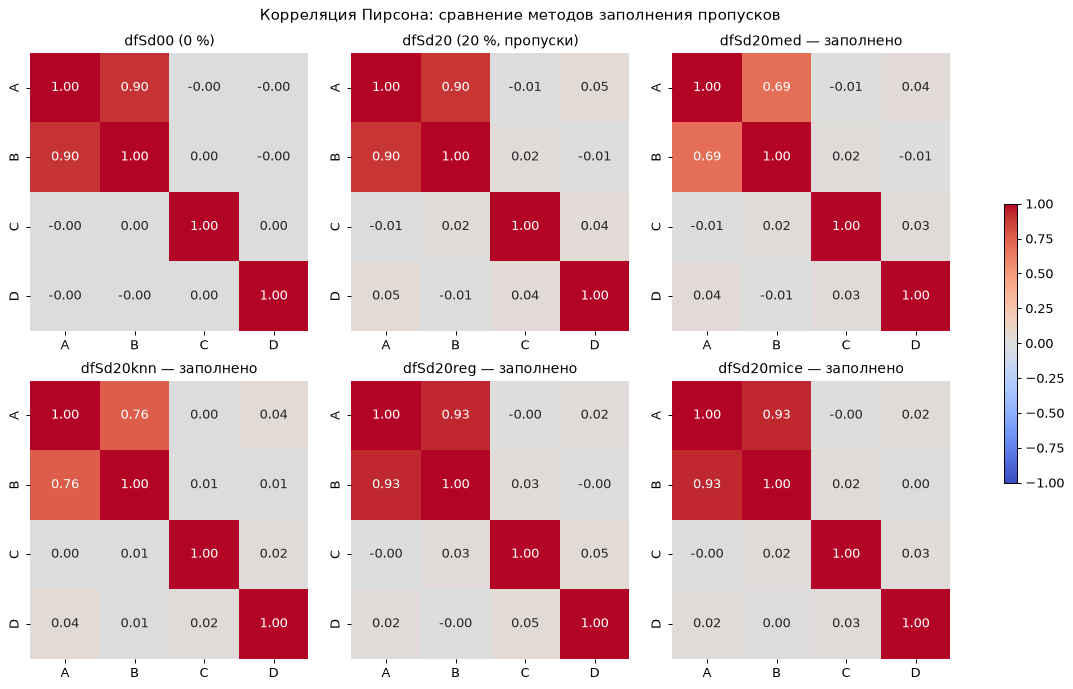

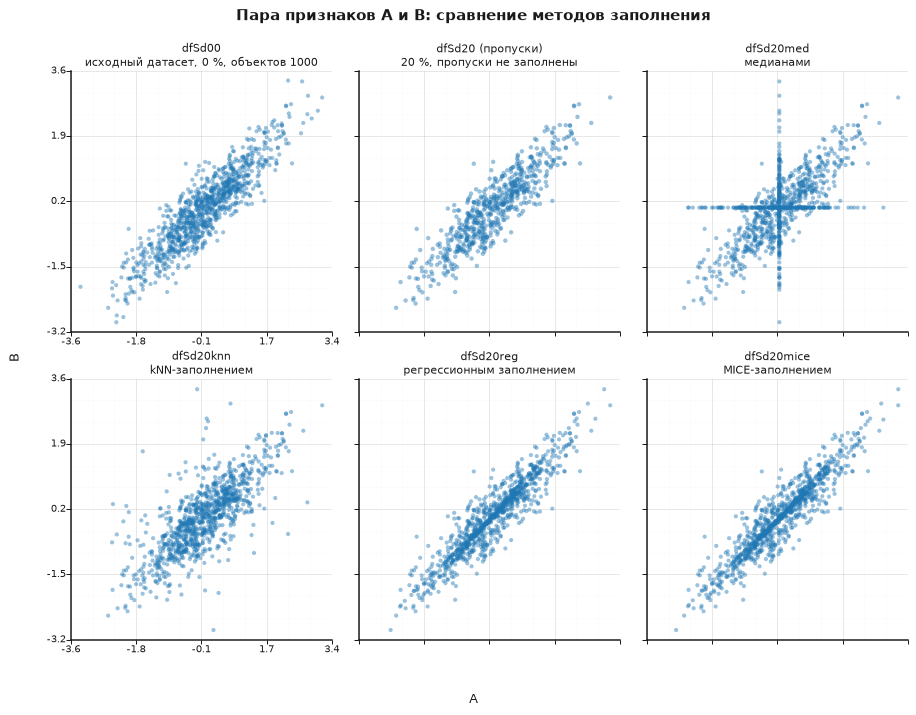

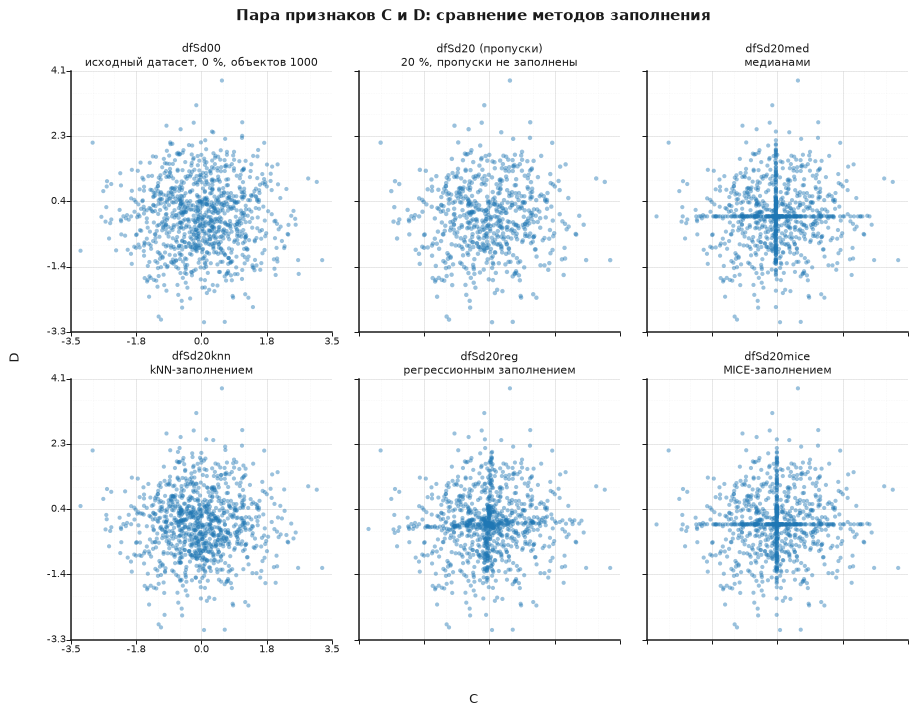

In [ ]:
METHODS_VIS = {
    "clone": "dfSd20",                 # любой из DF_SD
    "seed": 42,
    "pairs": [("A", "B"), ("C", "D")], # две выбираемые пары -> два панно
    "methods": {
        "med":  {"label": "медианами", "enabled": True},
        "knn":  {"label": "kNN-заполнением", "enabled": True,
                 "n_neighbors": 5, "weights": "distance"},
        "reg":  {"label": "регрессионным заполнением", "enabled": True,
                 "model": "linear"},          # "linear" | "ridge" | "forest"
        "mice": {"label": "MICE-заполнением", "enabled": True,
                 "n_iter": 10, "n_nearest_features": None, "tol": 1e-4},
    },
    "panel": {"ncols": 3, "cell_size": 2.9, "tick_labels": "outer", "legend": False},
}

METHODS_RESULT = run_methods_comparison(source=dfS00, clones=DF_SD,
                                        report=DELETION_REPORT)

## 9. [1.9] UpSet plot: пропуски и совпадающие значения

Оба вида построения сводятся к одному приёму: датасет превращается в таблицу
индикаторов 0/1, где столбец = 1, если объект принадлежит множеству этого признака.

* **(а) группировка пропусков** — индикатор `isna()`;
* **(б) группировка признаков** — признак совпадает, если `|x_i − x_k| ≤ tol`
  хотя бы для одного **другого** признака `k` той же строки. Тогда пересечение
  множеств означает ровно требуемое: объекты, у которых совпадают **все** признаки
  выбранной группы.

### Почему нужен допуск

Точных совпадений на непрерывных данных нет вообще: при `tol = 0` и `tol = 1e-9`
совпадений **0** во всех шести датасетах. Таблица чувствительности печатается
перед построением и показывает масштаб выбора.

### Проверка корректности

* сумма пересечений по пропускам `dfSd20` = 595 = числу строк с хотя бы одним
  пропуском;
* мощности множеств точно равны счётчикам `NaN`: 191 / 212 / 198 / 199;
* индикатор совпадений сверен с прямым вычислением по каждой строке и каждому
  признаку — **0 расхождений** из 16 000 проверок;
* теория сходится: для независимых $N(0,1)$, $P(|X-Y| \le 0.1) = \mathrm{erf}(0.05) = 0.0564$,
  то есть ожидалось ≈ 56 совпадений из 1000 — наблюдается 52 для пары C–D;
  для связанной пары A–B (r = 0.9) — 163, втрое больше.


14. UPSET PLOT: ПРОПУСКИ И СОВПАДАЮЩИЕ ЗНАЧЕНИЯ
Датасеты: ['dfSd00', 'dfSd20', 'dfSd20med', 'dfSd20knn', 'dfSd20reg', 'dfSd20mice']
Допуск для совпадений: 0.1
Сколько объектов имеют хотя бы одну пару совпадающих значений при разных допусках (для каждого датасета):
  допуск:             dfSd00          dfSd20       dfSd20med       dfSd20knn       dfSd20reg      dfSd20mice
  0                        0               0               0               0               0               0
  1e-09                    0               0               0               0               0               0
  0.01                    47              31              41              50              97              83
  0.05                   197             126             263             218             336             377
  0.1                    371             249             480             384             542             576
  0.25                   717             506             750             725    

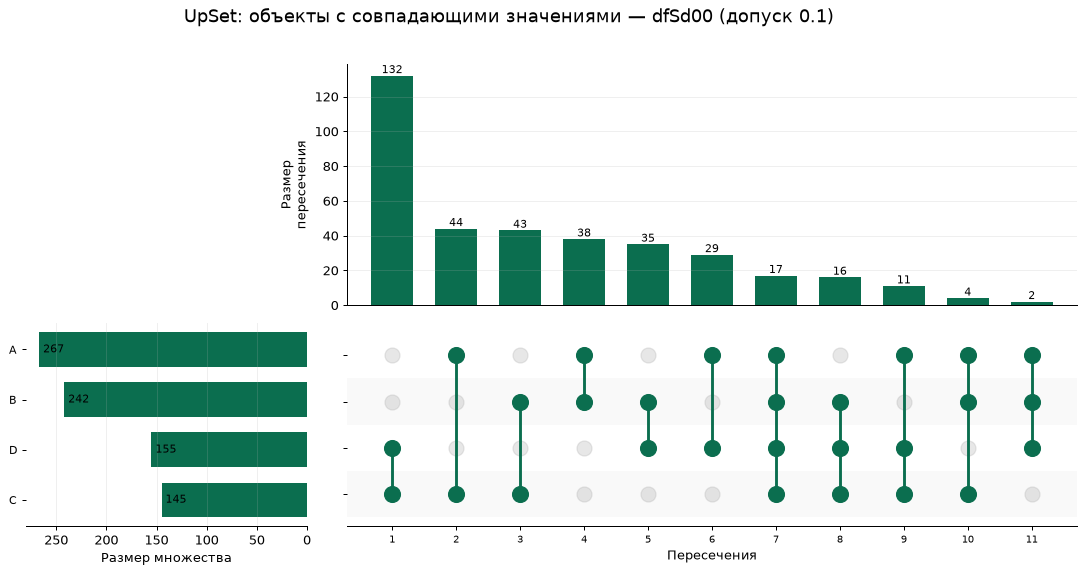

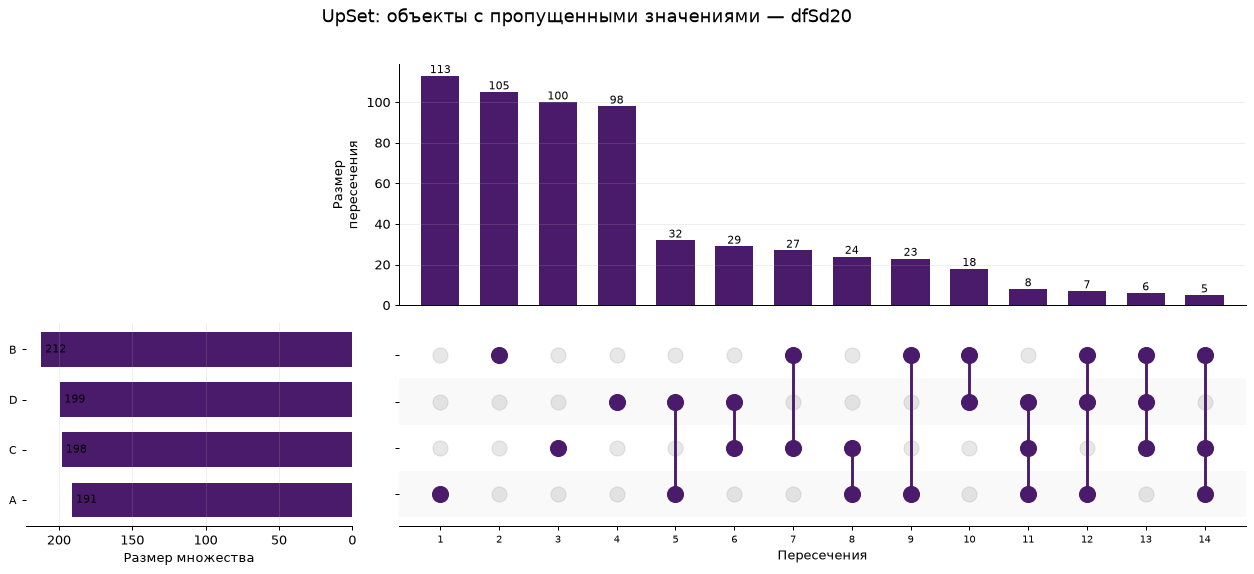

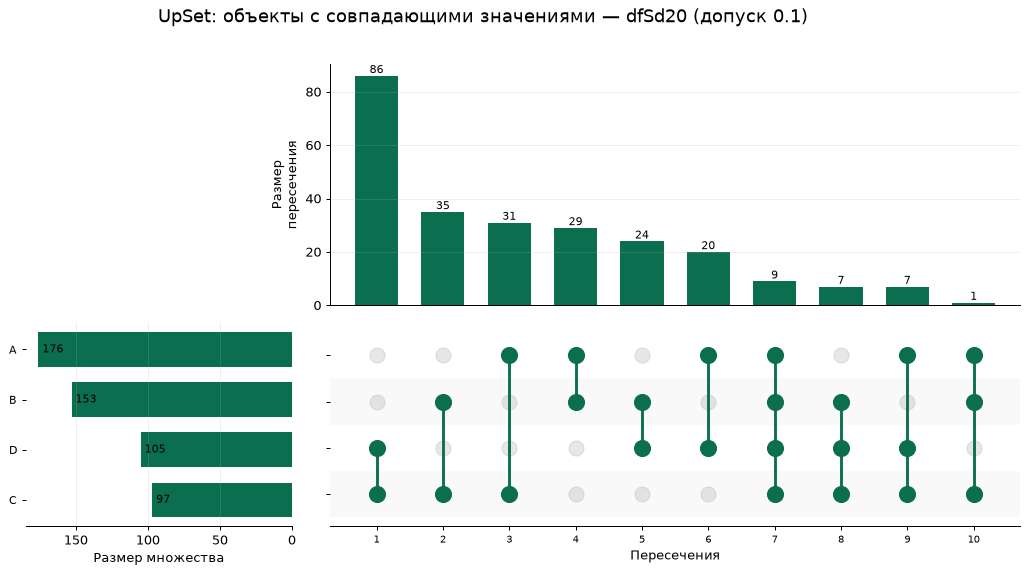

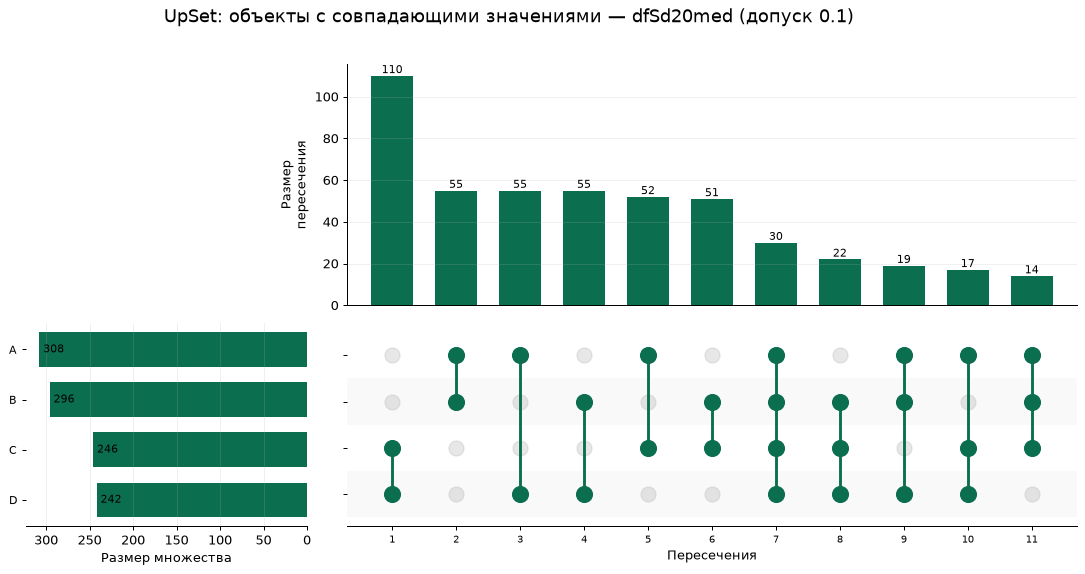

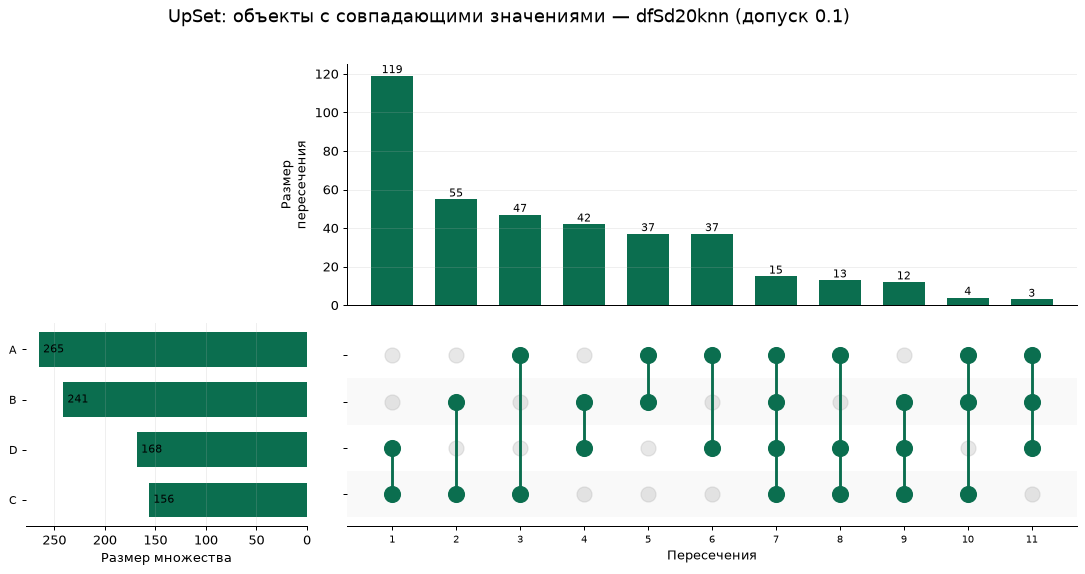

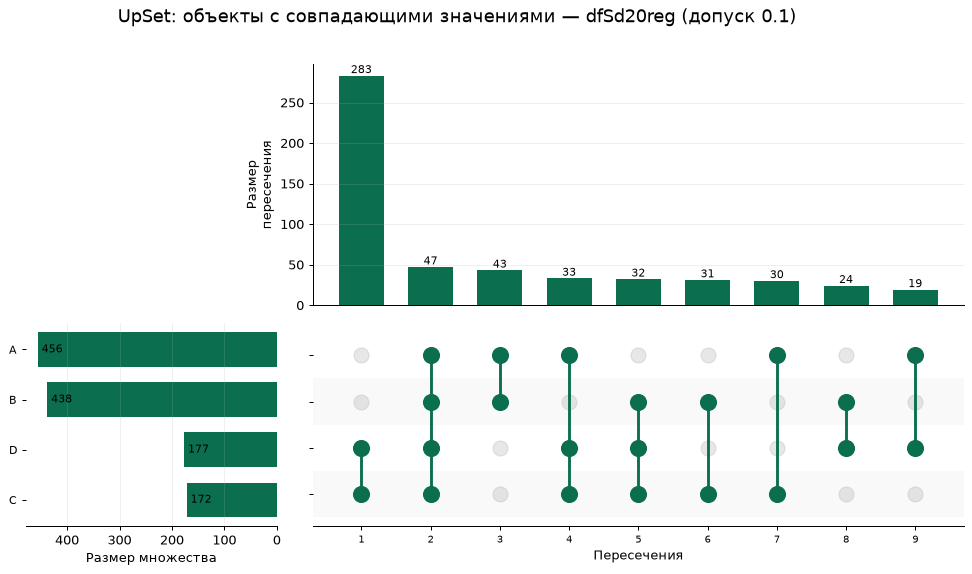

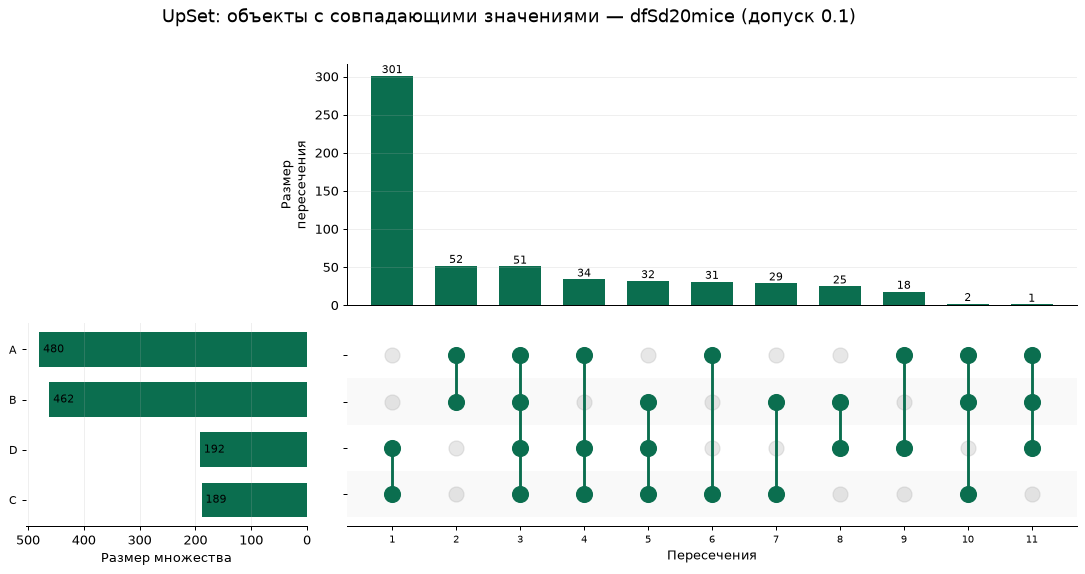

In [ ]:
UPSET_VIS = {
    "columns": ["A", "B", "C", "D"],
    "tolerance": 0.1,                                   # допуск для (б)
    "tolerance_report": [0.0, 1e-9, 0.01, 0.05, 0.1, 0.25, 0.5],
    "layout": "horizontal", "top_combinations": 15, "minimum_count": 1,
    "color": "#4A1A6B",             # пропуски
    "color_coincide": "#0B6E4F",    # совпадения
}

UPSET_DATASETS = {"dfSd00": dfS00, METHODS_VIS["clone"]: DF_SD[METHODS_VIS["clone"]]}
for _m in METHODS_VIS["methods"]:
    _k = f"{METHODS_VIS['clone']}{_m}"
    if _k in METHODS_RESULT["filled"]:
        UPSET_DATASETS[_k] = METHODS_RESULT["filled"][_k]

UPSET_FIGURES, UPSET_OUTPUTS = run_upset_analysis(UPSET_DATASETS)

Рисунки ниже идут в порядке построения: совпадения для `dfSd00`, `dfSd20med`,
`dfSd20knn`, `dfSd20reg`, `dfSd20mice`; затем **пропуски** для `dfSd20` —
единственный датасет, где они ещё есть; затем совпадения для самого клона
`dfSd20` с пропусками. У остальных пяти датасетов все множества пусты, поэтому
UpSet plot не строится вовсе — код сообщает об этом и не создаёт пустую фигуру.

## 10. [1.10] MNAR: пропуски, зависящие от значений

В `dfSdXX` ячейки удалялись **случайно** (MCAR) — пропуски не зависели от значений,
поэтому их можно было честно оценить. Здесь строится `dfMNAR`: у каждого объекта
удаляются все значения признаков C и D, которые **меньше признаковой медианы**.

Механизм пропуска зависит от значения: маленькие C и D исчезают **всегда**, большие
— **никогда**. Это и есть Missing Not At Random.

Получилось: удалено ровно 500 из 1000 ячеек в C и столько же в D; A и B не тронуты;
756 из 1000 строк имеют хотя бы один пропуск. Для `dfMNAR` выполняются **пункты
[1.8] и [1.9]** — тем же кодом, без дублирования.

### Почему здесь НИ ОДИН метод не работает

Наблюдаемая часть C и D — это ровно верхняя половина нормального распределения:

| признак | истинное среднее | наблюдаемое | истинная медиана | наблюдаемая |
|---|---|---|---|---|
| A, B | 0.000 | 0.000 | −0.027 | −0.027 |
| C | 0.000 | **+0.795** | +0.013 | **+0.668** |
| D | 0.000 | **+0.804** | −0.011 | **+0.672** |

Теория сходится: для $N(0,1)$ при обрезании по медиане среднее остатка = 0.798,
медиана = 0.674. Наблюдаемые 0.795 / 0.804 — в пределах выборочного разброса.

Все четыре метода смещены **одинаково**: заполненные значения C получаются
+0.668 (медиана), +0.810 (kNN), +0.799 (регрессия), +0.797 (MICE). Медиана
промахивается дальше всех, потому что берёт медиану обрезанной выборки, а не
истинную. Это неустранимо: нижняя половина распределения удалена безвозвратно, а
A и B с C и D независимы, поэтому предсказывать не по чему.

### Самое опасное следствие: ложная корреляция

| датасет | r(A,B) | r(A,C) | r(B,C) | ср. C |
|---|---|---|---|---|
| истина | 0.900 | 0.000 | 0.000 | 0.000 |
| `dfMNARmed` | 0.900 | **0.042** | **0.048** | **+0.731** |
| `dfMNARknn` | 0.900 | **0.080** | **0.096** | **+0.803** |
| `dfMNARreg` | 0.900 | **0.097** | **0.118** | **+0.797** |
| `dfMNARmice` | 0.900 | **0.080** | **0.092** | **+0.796** |

r(A,B) = 0.900 восстанавливается идеально — пропусков в этих признаках не было.
А вот нулевые по истине r(A,C) и r(B,C) «восстанавливаются» в 0.04…0.12: обрезанное
облако создаёт **ложную связь**, которая на heatmap выглядит правдоподобно. Именно
это и отличает MNAR от MCAR — и именно поэтому заполнение нельзя считать нейтральной
операцией.

### UpSet по MNAR

Только три пересечения: C (256), D (256), C∩D (244); сумма 756 совпадает с числом
строк с пропуском. Структура принципиально другая, чем у случайных пропусков
(14 пересечений, почти равномерные столбцы): здесь всего два непустых множества, а
A и B на график не попали вовсе, так как пропусков в них нет.

По совпадениям картина обратная: у `dfMNARmed` пересечение C∩D = 244 и
C∩D∩A∩B = 66 против 38 в исходном датасете — медианное заполнение кладёт 500
точек C и 500 точек D на две конкретные величины, поэтому «совпадения» возникают
искусственно.


15. MNAR: ПРОПУСКИ, ЗАВИСЯЩИЕ ОТ ЗНАЧЕНИЙ
Удаляются значения < медианы признаков ['C', 'D']

Что удалено (механизм пропуска зависит от значения!):
  C: медиана +0.0130, удалено 500 из 1000 (50.0 %)
  D: медиана -0.0105, удалено 500 из 1000 (50.0 %)
  всего удалено 1000 из 2000 ячеек (50.0 %)
  признаки A и B не тронуты: пропусков 0
  строк хотя бы с одним пропуском: 756 из 1000

------------------------------------------------------------
Пункт [1.8] для dfMNAR: четыре метода заполнения
------------------------------------------------------------
Выбранный клон: dfMNAR (удалено 25.0 % ячеек, пропусков в признаках: 1000)
  метод медианами                  -> пропусков после заполнения: 0
  метод kNN-заполнением            -> пропусков после заполнения: 0
  метод регрессионным заполнением  -> пропусков после заполнения: 0
  метод MICE-заполнением           -> пропусков после заполнения: 0
Строим heatmap корреляции Пирсона (оформление пункта [1.5]):
  dfMNAR (25.0 %, пропуски): max |Δr| 

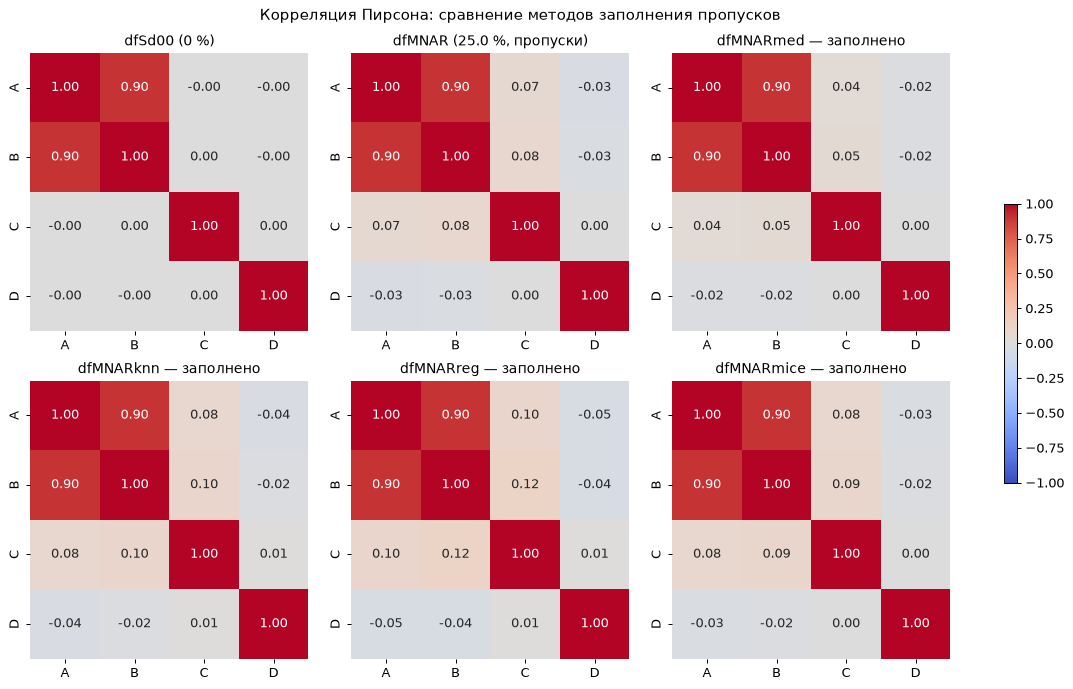

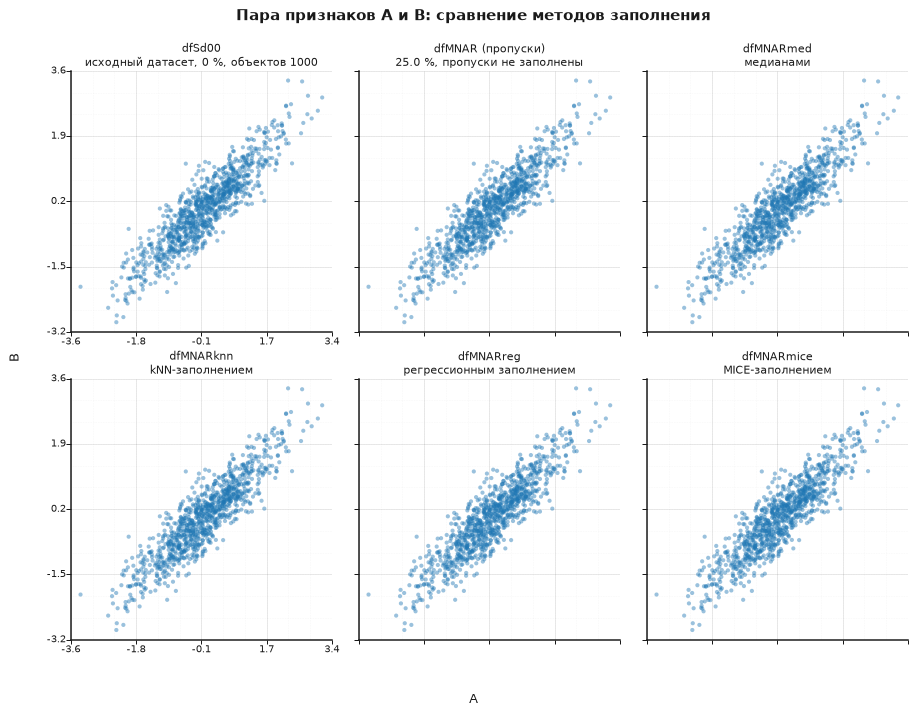

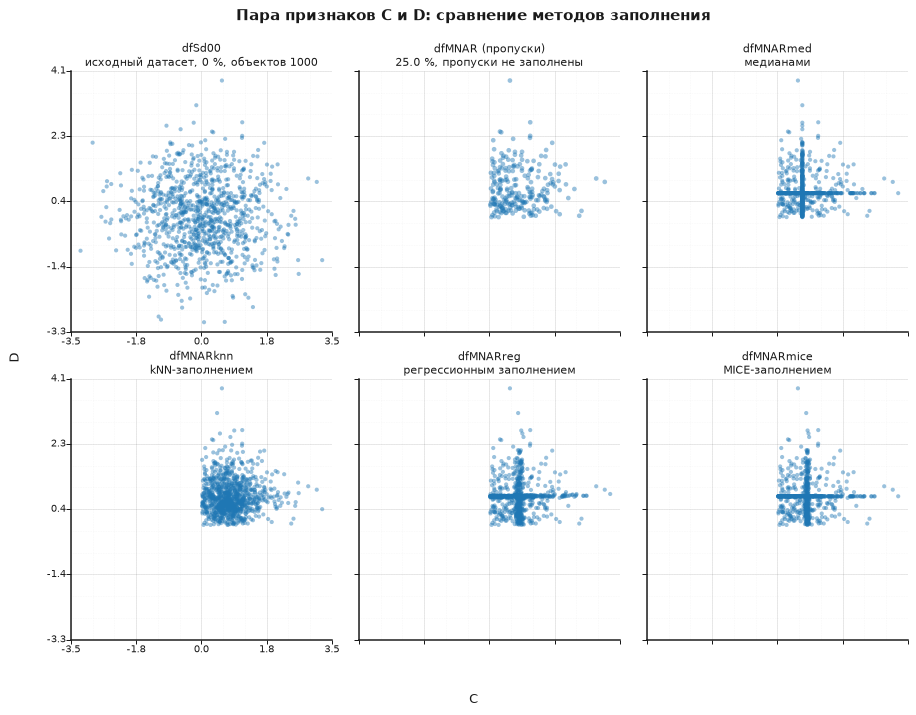

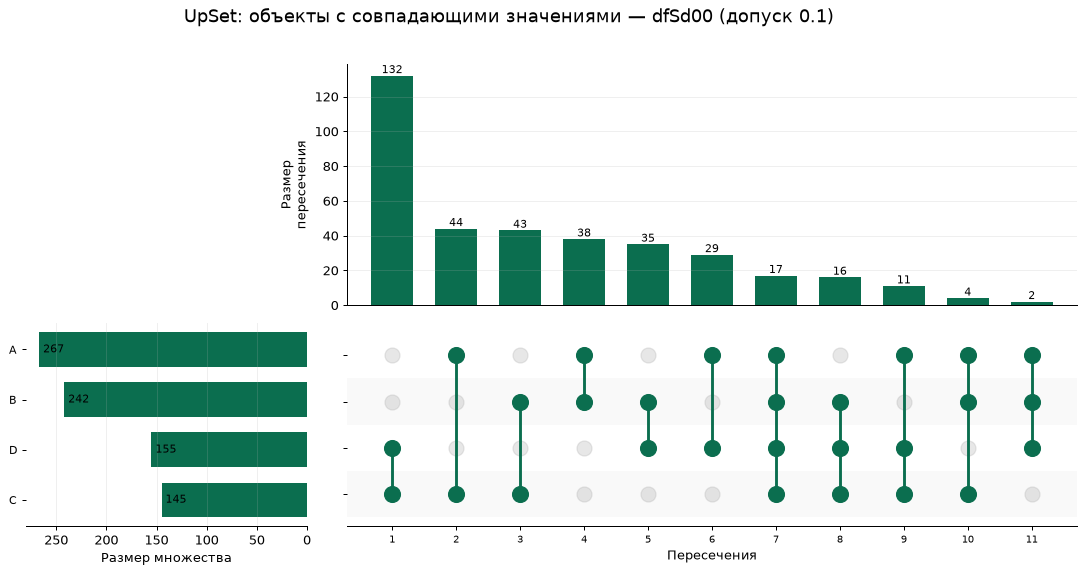

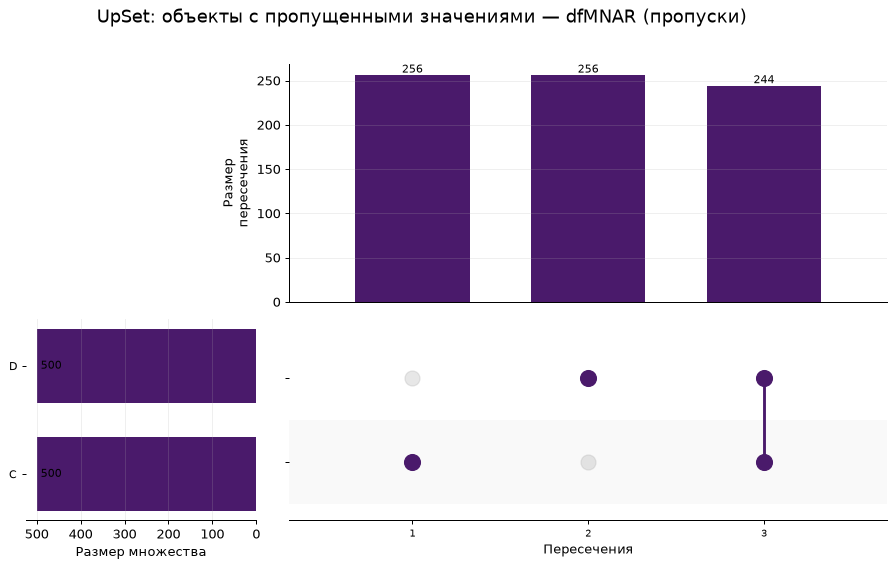

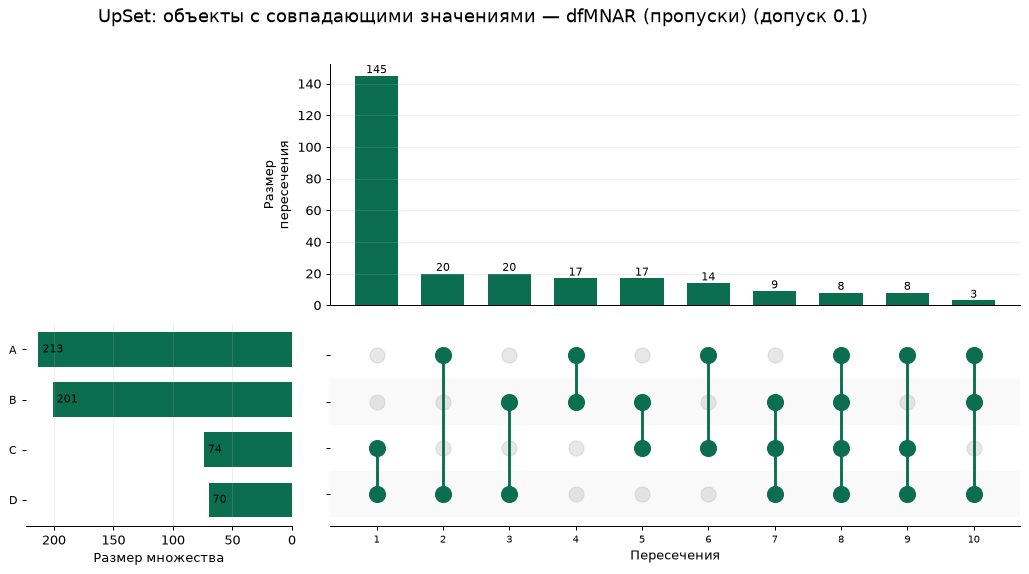

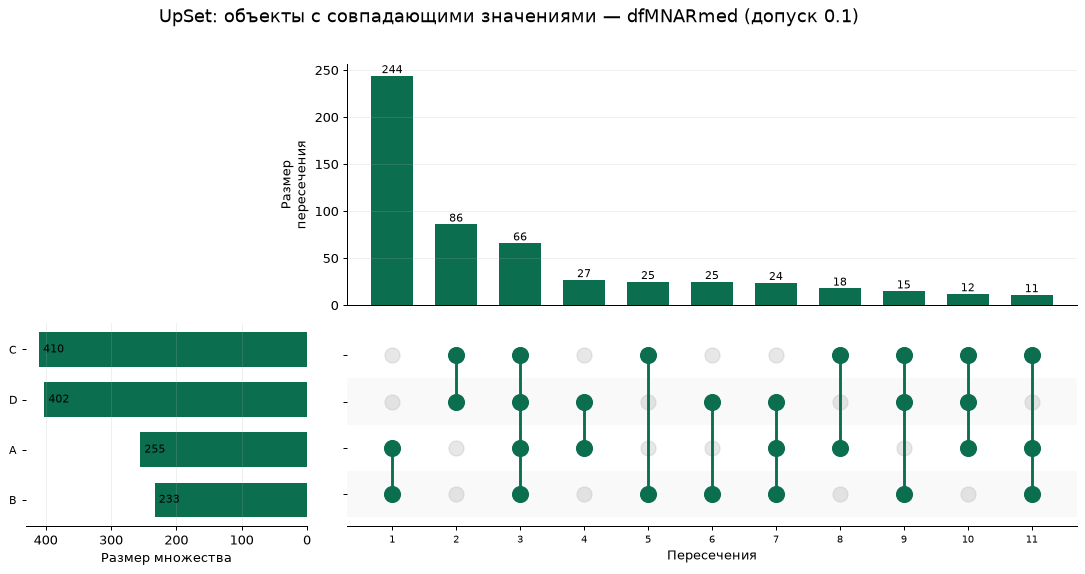

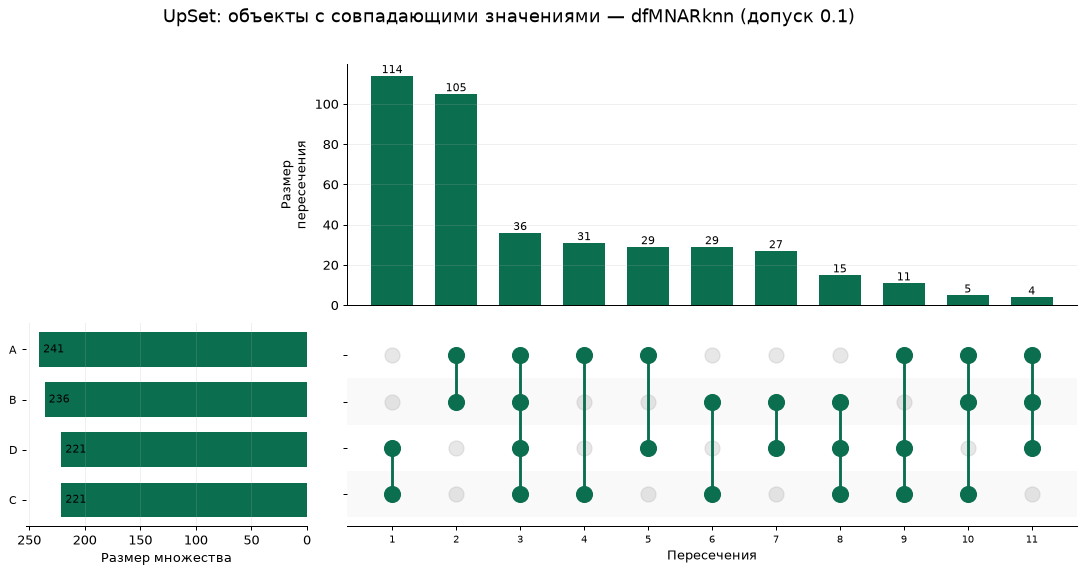

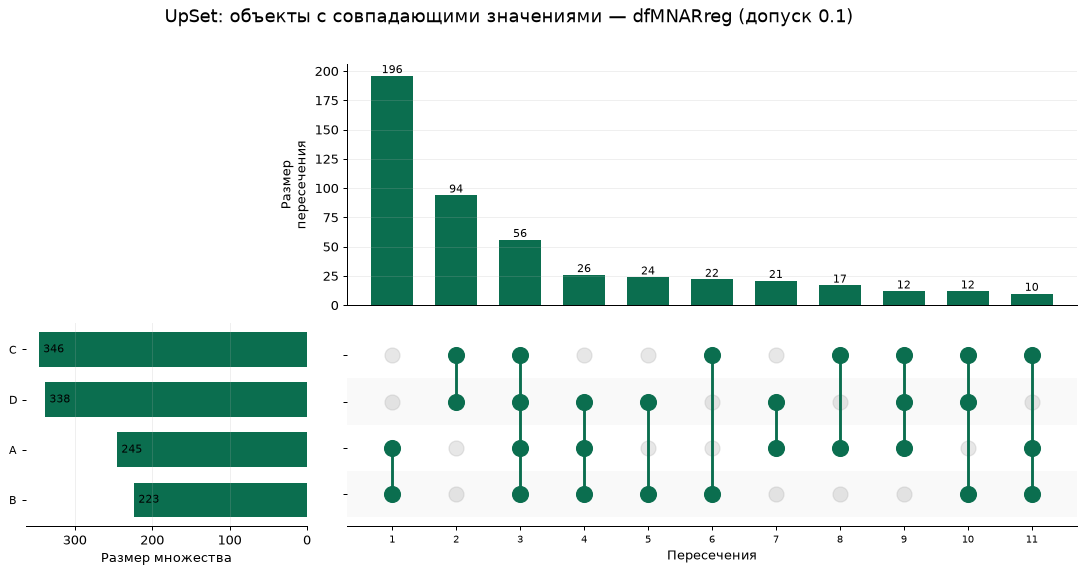

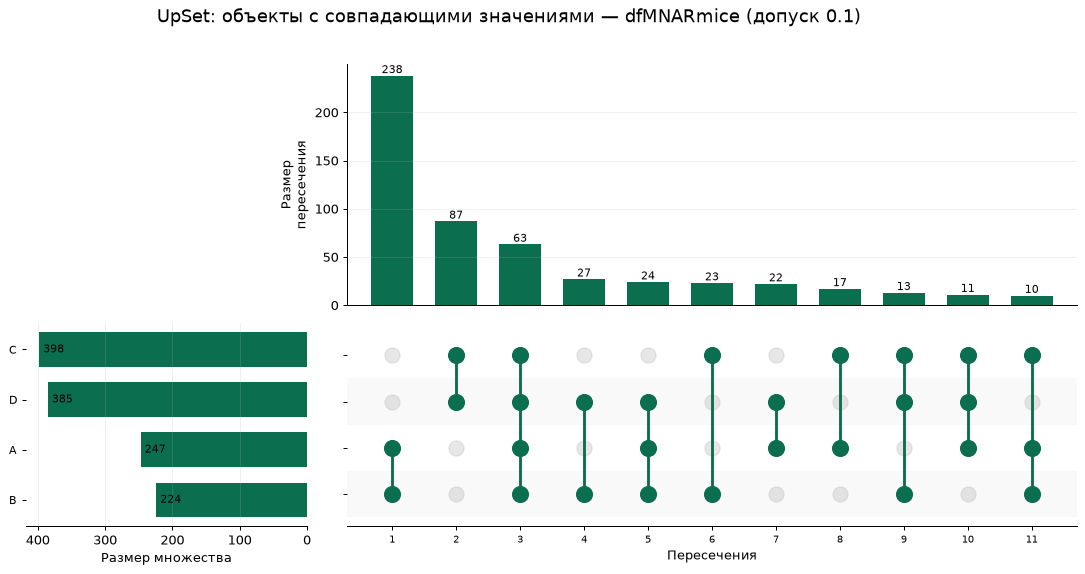

In [ ]:
MNAR_VIS = {
    "columns": ["C", "D"],       # признаки, значения которых удаляются
    "median_of": "column",       # медиана каждого столбца / из исходного dfS00
    "side": "below",             # удаляем значения < медианы
    "keep_equal": False,
    "name": "dfMNAR",
}

dfMNAR, MNAR_STATS = build_mnar_dataset(dfS00, source=dfS00)     # удалено 1000 ячеек
dfMNAR.attrs["name"] = MNAR_VIS["name"]

# ---- пункт [1.8] для dfMNAR -------------------------------------------------------
MNAR_RESULT   = run_mnar_methods(dfMNAR, source=dfS00)            # heatmap + 2 панно
MNAR_DATASETS = collect_comparison_datasets(MNAR_RESULT, "dfMNAR", dfS00)
MNAR_FIGURES, MNAR_OUTPUTS = run_upset_analysis(MNAR_DATASETS)   # пункт [1.9]

## 11. Выводы

### Визуализация (`[1.4]`)

* Совместное распределение A–B — вытянутое облако (r = 0.9); остальные пять пар
  визуально неотличимы от независимых.
* Один scatterplot не «показывает» корреляцию 0.9: нужны либо heatmap, либо
  совместная гистограмма/фигурная диаграмма. Соблазн считать «на глаз» по диаграмме
  рассеяния здесь особенно велик, потому что облака A–C и A–D выглядят одинаково.
* Маргинальные плотности подтверждают: все признаки нормированы и одинаковы по
  форме; информация лежит только в совместной структуре.

### Пропуски и заполнение (`[1.7]`, `[1.6]`, `[1.8]`)

* При 20 % удалённых ячеек на графике пары A–B остаётся 632 объекта, при 80 % —
  всего 37. Число точек на диаграмме падает **гораздо быстрее** доли удалённых
  ячеек: $1-(1-p)^{1/2}$ для одного признака и $1-(1-p)$ для пары.
* Восстановление пропусков всегда уменьшает разброс: стд заполненных значений
  ниже стд наблюдённых, и чем метод «умнее», тем сильнее (медиана 0.00,
  kNN 0.55, регрессия 0.87, MICE 0.90 для признака A).
* Метрика качества заполнения врёт: медиана даёт наименьшую суммарную ошибку
  корреляций, но катастрофически занижает r(A,B) — единственную связь, которая в
  данных есть.
* Регрессионное и MICE-заполнение кладут точки на почти точную прямую
  $A = 0.885\,B$: при 0.9-корреляции это неизбежно, но визуально облако выглядит
  «слишком узким», что легко принять за переобучение модели.

### UpSet (`[1.9]`)

* Случайные пропуски (MCAR) дают много пересечений и примерно равные мощности
  множеств; MNAR — два множества и три пересечения.
* Число совпадений значений на непрерывных данных определяется **допуском**:
  при `tol = 0` их нет вообще. Любой вывод о «совпадениях» без явного допуска
  некорректен.
* Заполнение пропусков **создаёт** совпадения: медиана даёт C∩D = 244 против 38
  в исходных данных.

### Главный вывод

Заполнение пропусков — не нейтральная операция, а статистическое допущение.
При MCAR (пропуски независимы от значений) медиана и регрессия дают несмещённые
оценки, и выигрыш определяется тем, насколько хорошо предсказывается признак по
остальным. При MNAR **любой** метод систематически смещает распределение вверх
(0.000 → ≈ 0.80) и может **создать ложные корреляции** там, где их не было.
Выбор метода заполнения нужно обосновывать механизмом возникновения пропусков, а
не только тем, что он даёт меньшую ошибку на контрольной выборке.